# Drift correciton for our field data


Load our tools (very important)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyproj import Proj
import netCDF4 as nc
from scipy.interpolate import interp1d
from datetime import datetime
import boule as bl

In [2]:
Data = pd.read_csv('./data_clean/CAGE-gravity.csv', skiprows=0, delimiter=r',')
GPS_Data = pd.read_csv('./data_clean/CAGE-gps.csv', skiprows=0, delimiter=r',')


In [3]:
Data.columns = Data.columns.str.strip()
GPS_Data.columns = GPS_Data.columns.str.strip()

Data.columns = Data.columns.str.strip()

for col in Data.select_dtypes(include='object'):
    Data[col] = Data[col].str.strip()

In [4]:
Data['Name'] = Data['Name'].str.strip()
GPS_Data['Name'] = GPS_Data['Name'].str.strip()

Data = pd.merge(Data, GPS_Data, on='Name', how='left')

In [5]:
Data['Gravity_non_drift']=Data['Gravity(milliGal)']-Data['Drift Correction(milliGal)']

In [6]:
Data

,# Time(UTC),Date(UTC),Time(Australia/Perth: UTC+8h),Date(Australia/Perth: UTC+8h),Name,Gravity(milliGal),Tilt Correction(milliGal),Temp Correction(milliGal),Drift Correction(milliGal),Std Dev (milliGal),...,Notes,Longitude,Latitude,ELLipSoidaL height,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,979378,Gravity_non_drift
0,4:15:35,2026/09/30,12:15:35,2026/09/30,Base Station,1248184.010,0.001486,0.159114,-217.294220,0.061195,...,1,116.210837,-31.521409,209.513,NaN,NaN,NaN,NaN,NaN,1.248401e+06
1,4:14:56,2026/09/30,12:14:56,2026/09/30,Base Station,1248183.961,0.003573,0.139656,-217.293237,0.062359,...,1,116.210837,-31.521409,209.513,NaN,NaN,NaN,NaN,NaN,1.248401e+06
2,4:14:24,2026/09/30,12:14:24,2026/09/30,Base Station,1248183.941,0.000560,0.105734,-217.292426,0.090799,...,1,116.210837,-31.521409,209.513,NaN,NaN,NaN,NaN,NaN,1.248401e+06
3,4:01:24,2026/09/30,12:01:24,2026/09/30,L3_S700,1248183.015,0.000176,0.252651,-217.272711,0.061795,...,1,116.209506,-31.519083,219.761,NaN,NaN,NaN,NaN,NaN,1.248400e+06
4,4:00:46,2026/09/30,12:00:46,2026/09/30,L3_S700,1248183.019,0.004087,0.252441,-217.271751,0.079185,...,1,116.209506,-31.519083,219.761,NaN,NaN,NaN,NaN,NaN,1.248400e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,5:41:46,2026/10/01,13:41:46,2026/10/01,L6_S300,1248179.700,0.004035,0.339614,-219.609470,0.069702,...,3,116.213746,-31.516463,231.979,NaN,NaN,NaN,NaN,NaN,1.248399e+06
140,5:41:09,2026/10/01,13:41:09,2026/10/01,L6_S300,1248179.681,0.011831,0.339590,-219.608525,0.063821,...,3,116.213746,-31.516463,231.979,NaN,NaN,NaN,NaN,NaN,1.248399e+06
141,5:15:47,2026/10/01,13:15:47,2026/10/01,Base Station,1248182.164,0.002538,0.335667,-219.570051,0.063660,...,3,116.210837,-31.521409,209.513,NaN,NaN,NaN,NaN,NaN,1.248402e+06
142,5:15:15,2026/10/01,13:15:15,2026/10/01,Base Station,1248182.166,0.000164,0.335855,-219.569240,0.068533,...,3,116.210837,-31.521409,209.513,NaN,NaN,NaN,NaN,NaN,1.248402e+06


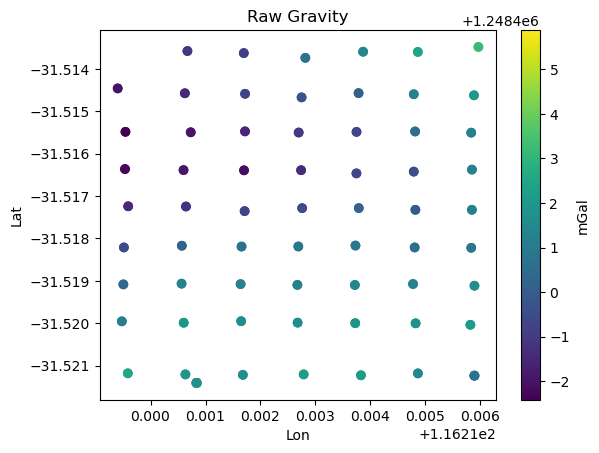

In [7]:
plt.scatter(Data.Longitude, Data.Latitude, c=Data['Gravity_non_drift'], cmap='viridis')

plt.xlabel('Lon')
plt.ylabel('Lat')
plt.title('Raw Gravity')
plt.colorbar(label='mGal')  # Adds a color scale legend


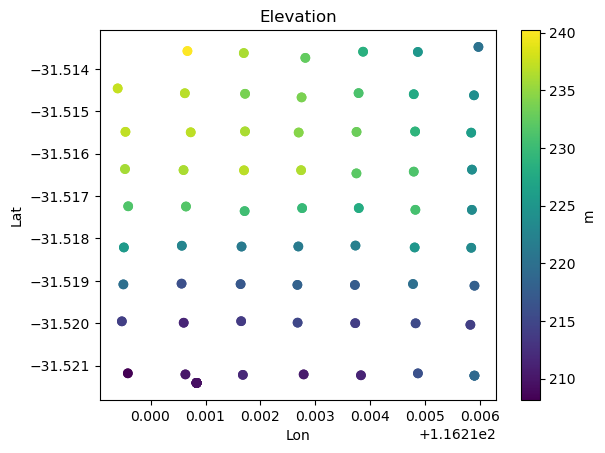

In [8]:
plt.scatter(Data.Longitude, Data.Latitude, c=Data['ELLipSoidaL height'], cmap='viridis')

plt.xlabel('Lon')
plt.ylabel('Lat')
plt.title('Elevation')
plt.colorbar(label='m')  # Adds a color scale legend


In [9]:
Data_1st_group = Data[Data.Notes==1]
Data_2nd_group = Data[Data.Notes==2]
Data_3nd_group = Data[Data.Notes==3]

In [10]:
Data_1st_group['Date(UTC)'] = pd.to_datetime(
    Data_1st_group['Date(UTC)'].str.strip(),
    format='%Y/%m/%d'
)

Data_1st_group['DateTime'] = pd.to_datetime(
    Data_1st_group['Date(UTC)'].dt.strftime('%Y-%m-%d')
    + ' '
    + Data_1st_group['# Time(UTC)'].str.strip(),
    format='%Y-%m-%d %H:%M:%S'
)

C:\Users\li353\AppData\Local\Temp\ipykernel_25052\3186844899.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_1st_group['Date(UTC)'] = pd.to_datetime(
C:\Users\li353\AppData\Local\Temp\ipykernel_25052\3186844899.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_1st_group['DateTime'] = pd.to_datetime(


In [11]:


Data_1st_group.loc[:,'DateTime'] = pd.to_datetime(Data_1st_group['DateTime'])

datetime_values = Data_1st_group['DateTime'].copy()
datetime_strings = [str(dt) for dt in datetime_values]

reference_time = min(datetime.strptime(dt, '%Y-%m-%d %H:%M:%S') for dt in datetime_strings)
seconds_elapsed = [(datetime.strptime(dt, '%Y-%m-%d %H:%M:%S') - reference_time).total_seconds() for dt in datetime_strings]
Data_1st_group.loc[:,'seconds_elapsed'] = seconds_elapsed
Data_control_1 = Data_1st_group[Data_1st_group.Name=='Base Station']


C:\Users\li353\AppData\Local\Temp\ipykernel_25052\2301232722.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_1st_group.loc[:,'seconds_elapsed'] = seconds_elapsed


In [12]:
Data_2nd_group['Date(UTC)'] = pd.to_datetime(
    Data_2nd_group['Date(UTC)'].str.strip(),
    format='%Y/%m/%d'
)

Data_2nd_group['DateTime'] = pd.to_datetime(
    Data_2nd_group['Date(UTC)'].dt.strftime('%Y-%m-%d')
    + ' '
    + Data_2nd_group['# Time(UTC)'].str.strip(),
    format='%Y-%m-%d %H:%M:%S'
)



Data_2nd_group.loc[:,'DateTime'] = pd.to_datetime(Data_2nd_group['DateTime'])

datetime_values = Data_2nd_group['DateTime'].copy()
datetime_strings = [str(dt) for dt in datetime_values]

reference_time = min(datetime.strptime(dt, '%Y-%m-%d %H:%M:%S') for dt in datetime_strings)
seconds_elapsed = [(datetime.strptime(dt, '%Y-%m-%d %H:%M:%S') - reference_time).total_seconds() for dt in datetime_strings]
Data_2nd_group.loc[:,'seconds_elapsed'] = seconds_elapsed
Data_control_2 = Data_2nd_group[Data_2nd_group.Name=='Base Station']



C:\Users\li353\AppData\Local\Temp\ipykernel_25052\3485077795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_2nd_group['Date(UTC)'] = pd.to_datetime(
C:\Users\li353\AppData\Local\Temp\ipykernel_25052\3485077795.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_2nd_group['DateTime'] = pd.to_datetime(
C:\Users\li353\AppData\Local\Temp\ipykernel_25052\3485077795.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [13]:
Data_3nd_group['Date(UTC)'] = pd.to_datetime(
    Data_3nd_group['Date(UTC)'].str.strip(),
    format='%Y/%m/%d'
)

Data_3nd_group['DateTime'] = pd.to_datetime(
    Data_3nd_group['Date(UTC)'].dt.strftime('%Y-%m-%d')
    + ' '
    + Data_3nd_group['# Time(UTC)'].str.strip(),
    format='%Y-%m-%d %H:%M:%S'
)



Data_3nd_group.loc[:,'DateTime'] = pd.to_datetime(Data_3nd_group['DateTime'])

datetime_values = Data_3nd_group['DateTime'].copy()
datetime_strings = [str(dt) for dt in datetime_values]

reference_time = min(datetime.strptime(dt, '%Y-%m-%d %H:%M:%S') for dt in datetime_strings)
seconds_elapsed = [(datetime.strptime(dt, '%Y-%m-%d %H:%M:%S') - reference_time).total_seconds() for dt in datetime_strings]
Data_3nd_group.loc[:,'seconds_elapsed'] = seconds_elapsed
Data_control_3 = Data_3nd_group[Data_3nd_group.Name=='Base Station']



C:\Users\li353\AppData\Local\Temp\ipykernel_25052\1534569507.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_3nd_group['Date(UTC)'] = pd.to_datetime(
C:\Users\li353\AppData\Local\Temp\ipykernel_25052\1534569507.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_3nd_group['DateTime'] = pd.to_datetime(
C:\Users\li353\AppData\Local\Temp\ipykernel_25052\1534569507.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_inde

In [14]:
df_1 = Data_1st_group[['Name','seconds_elapsed' ,'Gravity_non_drift']]
mean_Data_1 = df_1.groupby('Name').mean() # take mean of two measurements at each location
mean_Data_1.reset_index(inplace=True)

df_2 = Data_2nd_group[['Name','seconds_elapsed' ,'Gravity_non_drift']]
mean_Data_2 = df_2.groupby('Name').mean() # take mean of two measurements at each location
mean_Data_2.reset_index(inplace=True)

df_3 = Data_3nd_group[['Name','seconds_elapsed' ,'Gravity_non_drift']]
mean_Data_3 = df_3.groupby('Name').mean() # take mean of two measurements at each location
mean_Data_3.reset_index(inplace=True)

Text(0, 0.5, 'Gravity Drift (mGal)')

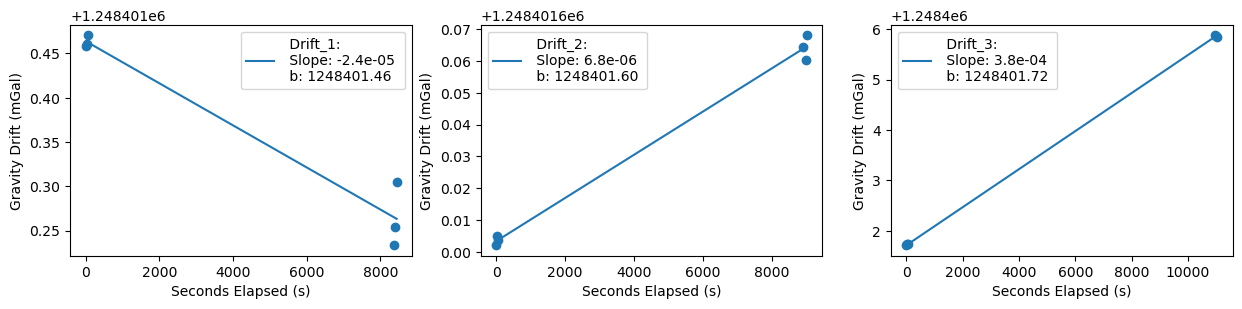

In [15]:
# That's our gravity drift

x_1 = np.array(Data_control_1['seconds_elapsed'])
y_1 = Data_control_1['Gravity_non_drift']
m_1, b_1 = np.polyfit(x_1, y_1, 1) 
slope_label_1 = f" Drift_1: \n Slope: {m_1:.1e} \n b: {b_1:.2f}"

Drift_1 = np.vstack((x_1, m_1*x_1 + b_1)).T


x_2 = np.array(Data_control_2['seconds_elapsed'])
y_2 = Data_control_2['Gravity_non_drift']
m_2, b_2 = np.polyfit(x_2, y_2, 1) 
slope_label_2 = f" Drift_2: \n Slope: {m_2:.1e} \n b: {b_2:.2f}"

Drift_2 = np.vstack((x_2, m_2*x_2 + b_2)).T

x_3 = np.array(Data_control_3['seconds_elapsed'])
y_3 = Data_control_3['Gravity_non_drift']
m_3, b_3 = np.polyfit(x_3, y_3, 1) 
slope_label_3 = f" Drift_3: \n Slope: {m_3:.1e} \n b: {b_3:.2f}"

Drift_3 = np.vstack((x_3, m_3*x_3 + b_3)).T

plt.figure(figsize=(15,3))
plt.subplot(1,3,1)
plt.scatter(x_1, y_1)
plt.plot(x_1, m_1*x_1 + b_1, label=slope_label_1)
plt.legend()
plt.xlabel('Seconds Elapsed (s)')
plt.ylabel('Gravity Drift (mGal)')

plt.subplot(1,3,2)
plt.scatter(x_2, y_2)
plt.plot(x_2, m_2*x_2 + b_2, label=slope_label_2)
plt.legend()
plt.xlabel('Seconds Elapsed (s)')
plt.ylabel('Gravity Drift (mGal)')

plt.subplot(1,3,3)
plt.scatter(x_3, y_3)
plt.plot(x_3, m_3*x_3 + b_3, label=slope_label_3)
plt.legend()
plt.xlabel('Seconds Elapsed (s)')
plt.ylabel('Gravity Drift (mGal)')

In [16]:
# group by station (taking the mean here)
df_1 = Data_1st_group[['Name', 'seconds_elapsed','Gravity_non_drift', 'Longitude', 'Latitude', 'ELLipSoidaL height']]
df_1 = df_1[df_1['Name']!='Base Station']
mean_Data_1 = df_1.groupby(['Name']).mean() # take mean of three measurements at each location
mean_Data_1.reset_index(inplace=True)

df_2 = Data_2nd_group[['Name', 'seconds_elapsed','Gravity_non_drift', 'Longitude', 'Latitude', 'ELLipSoidaL height']]
df_2 = df_2[df_2['Name']!='Base Station']
mean_Data_2 = df_2.groupby(['Name']).mean() # take mean of three measurements at each location
mean_Data_2.reset_index(inplace=True)

df_3 = Data_3nd_group[['Name', 'seconds_elapsed','Gravity_non_drift', 'Longitude', 'Latitude', 'ELLipSoidaL height']]
df_3 = df_3[df_3['Name']!='Base Station']
mean_Data_3 = df_3.groupby(['Name']).mean() # take mean of three measurements at each location
mean_Data_3.reset_index(inplace=True)

Text(0.5, 1.0, 'Day 2')

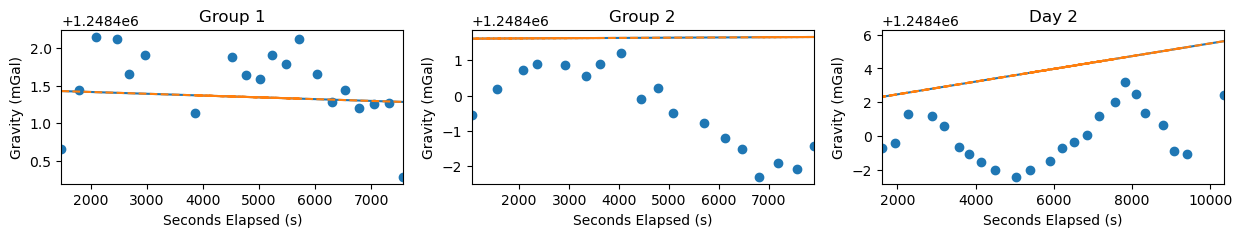

In [17]:
# Let's look at out data

x_new_1 = mean_Data_1['seconds_elapsed']
f_1 = interp1d(Drift_1[:,0],Drift_1[:,1], kind='linear')
drift_1 = f_1(x_new_1)

x_new_2 = mean_Data_2['seconds_elapsed']
f_2 = interp1d(Drift_2[:,0],Drift_2[:,1], kind='linear')
drift_2 = f_2(x_new_2)

x_new_3 = mean_Data_3['seconds_elapsed']
f_3 = interp1d(Drift_3[:,0],Drift_3[:,1], kind='linear')
drift_3 = f_3(x_new_3)

plt.figure(figsize=(15,2))
plt.subplot(1,3,1)
plt.plot(Drift_1[:,0],Drift_1[:,1])
plt.scatter(mean_Data_1['seconds_elapsed'], mean_Data_1['Gravity_non_drift'])
plt.plot(x_new_1,drift_1, linestyle='--')
plt.xlim(min(mean_Data_1['seconds_elapsed']), max(mean_Data_1['seconds_elapsed']))
plt.xlabel('Seconds Elapsed (s)')
plt.ylabel('Gravity (mGal)')
plt.title('Group 1')

plt.subplot(1,3,2)
plt.plot(Drift_2[:,0],Drift_2[:,1])
plt.scatter(mean_Data_2['seconds_elapsed'], mean_Data_2['Gravity_non_drift'])
plt.plot(x_new_2,drift_2, linestyle='--')
plt.xlim(min(mean_Data_2['seconds_elapsed']), max(mean_Data_2['seconds_elapsed']))
plt.xlabel('Seconds Elapsed (s)')
plt.ylabel('Gravity (mGal)')
plt.title('Group 2')

plt.subplot(1,3,3)
plt.plot(Drift_3[:,0],Drift_3[:,1])
plt.scatter(mean_Data_3['seconds_elapsed'], mean_Data_3['Gravity_non_drift'])
plt.plot(x_new_3,drift_3, linestyle='--')
plt.xlim(min(mean_Data_3['seconds_elapsed']), max(mean_Data_3['seconds_elapsed']))
plt.xlabel('Seconds Elapsed (s)')
plt.ylabel('Gravity (mGal)')
plt.title('Day 2')

In [18]:
drift_1

array([1248401.42863374, 1248401.42138739, 1248401.41385641,
       1248401.4052106 , 1248401.39983811, 1248401.39341009,
       1248401.32800322, 1248401.33357733, 1248401.33932934,
       1248401.34446464, 1248401.35035896, 1248401.35628887,
       1248401.37216916, 1248401.32021132, 1248401.31419839,
       1248401.30854126, 1248401.30246904, 1248401.29617148,
       1248401.28996879, 1248401.28384913])

In [19]:
drift_corrected_1 = mean_Data_1['Gravity_non_drift'] - drift_1
drift_corrected_2 = mean_Data_2['Gravity_non_drift'] - drift_2
drift_corrected_3 = mean_Data_3['Gravity_non_drift'] - drift_3

mean_Data_1['grav_drift'] = drift_corrected_1
mean_Data_2['grav_drift'] = drift_corrected_2
mean_Data_3['grav_drift'] = drift_corrected_3

#Save to file
combined = pd.concat([mean_Data_1,mean_Data_2,mean_Data_3])
combined.to_csv('Processed_Data.csv')

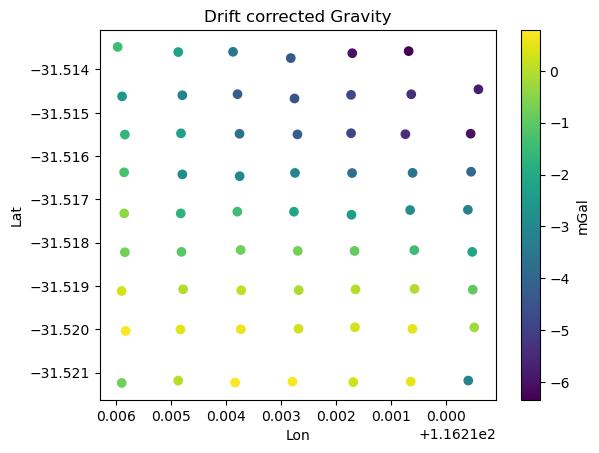

In [20]:
plt.scatter(combined.Longitude, combined.Latitude, c=combined['grav_drift'], cmap='viridis')
#plt.xlim(0,30)
#plt.ylim(150,550)
plt.xlabel('Lon')
plt.ylabel('Lat')
plt.title('Drift corrected Gravity')
plt.colorbar(label='mGal')  # Adds a color scale legend
plt.gca().invert_xaxis()

In [21]:
line_number=200 #You could change number in here to look different line

plt.figure(figsize=(8,2))
plt.scatter(combined.STATION[combined.LINE==line_number],combined['grav_drift'][combined.LINE==line_number])
even_ticks = np.arange(2, 30, 2)
plt.xticks(even_ticks)

plt.xlabel('Station')
plt.ylabel('Drift corrected Gravity(mGal)')
plt.title('Line %d' %line_number)
plt.gca().invert_xaxis()

AttributeError: 'DataFrame' object has no attribute 'STATION'

<Figure size 800x200 with 0 Axes>

In [ ]:
line_number=200 #You could change number in here to look different line

plt.figure(figsize=(8,2))
plt.scatter(combined.STATION[combined.LINE==line_number],combined['Height_Ellipsoid_m'][combined.LINE==line_number])
even_ticks = np.arange(2, 30, 2)
plt.xticks(even_ticks)

plt.xlabel('Station')
plt.ylabel('Elevation (m)')
plt.title('Line %d' %line_number)
plt.gca().invert_xaxis()

In [ ]:
plt.scatter(combined.STATION, combined.LINE, c=combined['grav_drift'], cmap='viridis')
plt.xlim(0,30)
plt.ylim(150,550)
plt.xlabel('Station')
plt.ylabel('Line')
plt.title('Drift corrected Gravity')
plt.colorbar(label='mGal')  # Adds a color scale legend
plt.gca().invert_xaxis()